# Part 1: suppervised Learning 

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
df=pd.read_csv(r"C:\Users\aesha\OneDrive\سطح المكتب\2014.csv", low_memory=False)
df.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENUM,...,_FOBTFS,_CRCREC,_AIDTST3,_IMPEDUC,_IMPMRTL,_IMPHOME,RCSBRAC1,RCSRACE1,RCHISLA1,RCSBIRTH
0,1,1,b'01172014',b'01',b'17',b'2014',1100,2014000001,2014000001,1.0,...,2.0,1.0,2.0,5,1,1,NaN,b'',b'',b''
1,1,1,b'01072014',b'01',b'07',b'2014',1100,2014000002,2014000002,1.0,...,2.0,2.0,2.0,4,1,1,NaN,b'',b'',b''
2,1,1,b'01092014',b'01',b'09',b'2014',1100,2014000003,2014000003,1.0,...,2.0,2.0,2.0,6,1,1,NaN,b'',b'',b''
3,1,1,b'01072014',b'01',b'07',b'2014',1100,2014000004,2014000004,1.0,...,2.0,1.0,2.0,6,3,1,NaN,b'',b'',b''
4,1,1,b'01162014',b'01',b'16',b'2014',1100,2014000005,2014000005,1.0,...,2.0,1.0,2.0,5,1,1,NaN,b'',b'',b''


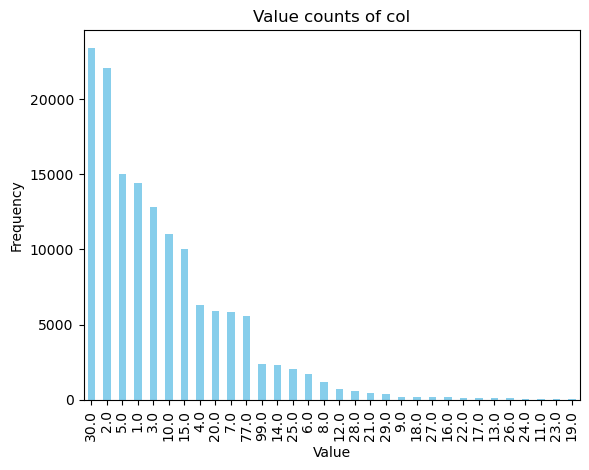

In [3]:
df = df[df['MENTHLTH'] != 88.0]
import pandas as pd
import matplotlib.pyplot as plt

# example df
# df = pd.DataFrame({'col': [...]})

# compute frequencies
counts = df['MENTHLTH'].value_counts()

# plot as bar chart
counts.plot(kind='bar', color='skyblue')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Value counts of col')
plt.show()

In [4]:
exclude = [1.0,20.,14., 77., 4., 12., 25., 3., 10.,
           7., 8., 6., 28., 17., 16., 21., 99., 27.,
           22., 23., 29., 18., 11., 9., 13., 26., 24., 19.,88.]

df = df[~df['MENTHLTH'].isin(exclude)]


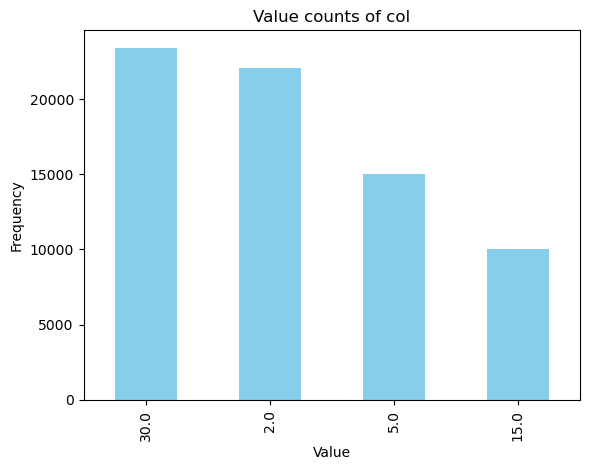

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# example df
# df = pd.DataFrame({'col': [...]})

# compute frequencies
counts = df['MENTHLTH'].value_counts()

# plot as bar chart
counts.plot(kind='bar', color='skyblue')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Value counts of col')
plt.show()

In [6]:
len(df)

70578

In [7]:
import pandas as pd
import numpy as np

def preprocess_and_engineer_selective(df: pd.DataFrame,
                                      mh_col: str = 'MENTHLTH',
                                      good_value: float = 5.0,
                                      keep_raw: list | None = None):
    """
    - Takes raw DataFrame df
    - Creates a binary mental-health label y (0 = good, 1 = bad) based on mh_col
    - Feature-engineers new features (age, BMI, sleep, comorbidity, lifestyle, etc.)
    - Drops the rest of raw columns except those in keep_raw (if provided)
    - Returns (X, y) where:
       X: DataFrame of engineered + optionally selected raw features
       y: pandas Series, binary target
    """

    df2 = df.copy()
    df2.columns = df2.columns.str.strip()
    # fill NaNs globally
    df2 = df2.fillna(0)

    # create binary label
    df2['mh_label'] = np.where(df2.get(mh_col, 0) <= good_value, 0, 1)

    feature_dict = {}

    # 1. Age-based if available
    if '_AGE80' in df2.columns:
        feature_dict['age'] = df2['_AGE80']
        feature_dict['age_squared'] = df2['_AGE80'] ** 2
        feature_dict['is_senior'] = (df2['_AGE80'] >= 65).astype(int)

    # 2. BMI / weight-related if available
    if '_BMI5' in df2.columns:
        feature_dict['BMI'] = df2['_BMI5']
        feature_dict['BMI_underweight'] = (df2['_BMI5'] < 18.5).astype(int)
        feature_dict['BMI_overweight_or_obese'] = (df2['_BMI5'] >= 25).astype(int)

    # 3. Sleep features
    if 'SLEPTIM1' in df2.columns:
        feature_dict['sleep_hours'] = df2['SLEPTIM1']
        feature_dict['sleep_short'] = (df2['SLEPTIM1'] < 6).astype(int)
        feature_dict['sleep_long'] = (df2['SLEPTIM1'] > 9).astype(int)

    # 4. Chronic-disease burden features
    chronic_cols = [
        'CVDINFR4','CVDCRHD4','CVDSTRK3',
        'ASTHMA3','CHCCOPD1','CHCKIDNY','DIABETE3'
    ]
    existing = [c for c in chronic_cols if c in df2.columns]
    if existing:
        feature_dict['num_chronic'] = df2[existing].sum(axis=1).astype(int)
        feature_dict['has_chronic'] = (df2[existing].sum(axis=1) > 0).astype(int)

    # 5. Health status difference (if both physical & mental health exist)
    if ('PHYSHLTH' in df2.columns) and ('MENTHLTH' in df2.columns):
        feature_dict['phys_vs_mental_diff'] = df2['PHYSHLTH'] - df2['MENTHLTH']

    # 6. Lifestyle / behavior features
    if 'SMOKE100' in df2.columns:
        feature_dict['smoker_ever'] = (df2['SMOKE100'] == 1).astype(int)
    if 'ALCDAY5' in df2.columns:
        feature_dict['drinks_regularly'] = (df2['ALCDAY5'] > 0).astype(int)
    if 'EXERANY2' in df2.columns:
        feature_dict['exercise_flag'] = (df2['EXERANY2'] == 1).astype(int)

    # 7. Combined “unhealthy lifestyle” score
    # (sum of risk-behaviors: smoking + drinking + not exercising + overweight/obese + poor sleep)
    lifestyle_components = []
    if 'smoker_ever' in feature_dict: lifestyle_components.append(feature_dict['smoker_ever'])
    if 'drinks_regularly' in feature_dict: lifestyle_components.append(feature_dict['drinks_regularly'])
    if 'exercise_flag' in feature_dict: lifestyle_components.append((1 - feature_dict['exercise_flag']))  # 1 if no exercise
    if 'BMI_overweight_or_obese' in feature_dict: lifestyle_components.append(feature_dict['BMI_overweight_or_obese'])
    if 'sleep_short' in feature_dict: lifestyle_components.append(feature_dict['sleep_short'])
    if 'sleep_long' in feature_dict: lifestyle_components.append(feature_dict.get('sleep_long', 0))

    if lifestyle_components:
        # sum up all binary components
        feature_dict['unhealthy_lifestyle_score'] = np.sum(lifestyle_components, axis=0).astype(int)

    # 8. (Optional) include some raw demographic variables if user wants to keep them
    df_features = pd.DataFrame(feature_dict, index=df2.index)
    if keep_raw:
        raw_keep = [c for c in keep_raw if c in df2.columns]
        df_keep = df2[raw_keep].reset_index(drop=True)
        X = pd.concat([df_keep, df_features.reset_index(drop=True)], axis=1)
    else:
        X = df_features.reset_index(drop=True)

    y = df2['mh_label'].astype(int).reset_index(drop=True)

    return X, y


In [8]:
X,y= preprocess_and_engineer_selective(df)

In [9]:
X.head()


,age,age_squared,is_senior,BMI,BMI_underweight,BMI_overweight_or_obese,sleep_hours,sleep_short,sleep_long,num_chronic,has_chronic,phys_vs_mental_diff,smoker_ever,drinks_regularly,exercise_flag,unhealthy_lifestyle_score
0,61,3721,0,2551.0,0,1,9,0,0,9,1,20.0,1,1,0,4
1,39,1521,0,2179.0,0,1,8,0,0,15,1,86.0,0,1,1,2
2,70,4900,1,3081.0,0,1,2,1,0,15,1,86.0,0,1,1,3
3,41,1681,0,3863.0,0,1,5,1,0,15,1,15.0,1,1,0,5
4,76,5776,1,3255.0,0,1,8,0,0,12,1,58.0,1,1,1,3


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\aesha\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
180 fits failed out of a total of 540.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\aesha\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\aesha\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\aesha\anaconda3\Lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_estimator.f

Best parameters: {'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}
Best score: 0.9232403425217186


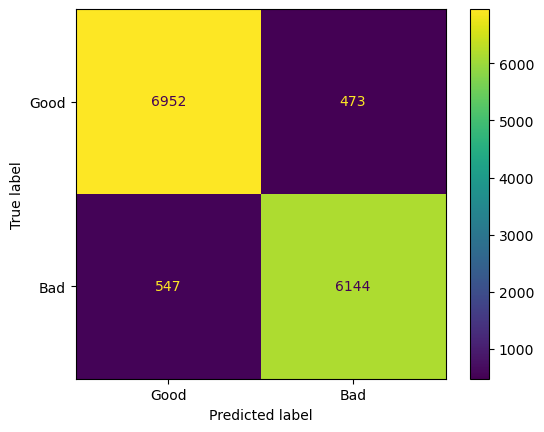

In [11]:
# Applying GridSearchCV for RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Define parameter grid
# Define parameter grid
# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_features': ['auto', 'sqrt', 'log2'],
    'classifier__max_depth': [None, 4, 6, 8, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}


# Initialize GridSearchCV
clf_Au = GridSearchCV(pipeline, param_grid, cv=5, verbose=True, n_jobs=-1)

# Fit model
clf_Au.fit(X_train, y_train)

# Best parameters and score
print(f'Best parameters: {clf_Au.best_params_}')
print(f'Best score: {clf_Au.best_score_}')

predictions = clf_Au.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf_Au.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Good","Bad"])
disp.plot()
plt.show()


In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
y_pred_rf = clf_Au.predict(X_test)
y_prob_rf = clf_Au.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_prob_rf)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
0:	learn: 0.5375886	total: 165ms	remaining: 1m 5s
1:	learn: 0.4562430	total: 181ms	remaining: 36s
2:	learn: 0.4046064	total: 196ms	remaining: 25.9s
3:	learn: 0.3661341	total: 212ms	remaining: 21s
4:	learn: 0.3301334	total: 229ms	remaining: 18.1s
5:	learn: 0.3085269	total: 245ms	remaining: 16.1s
6:	learn: 0.2863713	total: 262ms	remaining: 14.7s
7:	learn: 0.2783883	total: 277ms	remaining: 13.6s
8:	learn: 0.2613258	total: 293ms	remaining: 12.7s
9:	learn: 0.2515730	total: 309ms	remaining: 12s
10:	learn: 0.2452069	total: 324ms	remaining: 11.4s
11:	learn: 0.2348577	total: 340ms	remaining: 11s
12:	learn: 0.2264327	total: 357ms	remaining: 10.6s
13:	learn: 0.2194749	total: 373ms	remaining: 10.3s
14:	learn: 0.2149909	total: 389ms	remaining: 9.97s
15:	learn: 0.2088568	total: 407ms	remaining: 9.76s
16:	learn: 0.2041928	total: 425ms	remaining: 9.57s
17:	learn: 0.2007086	total: 441ms	remaining: 9.35s
18:	learn: 0.1983864	total: 455ms	rema

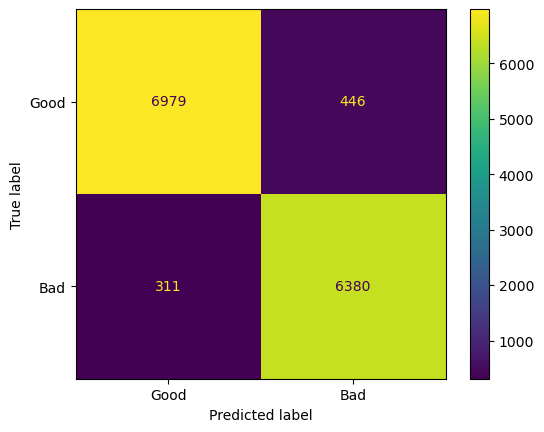

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Create pipeline (CatBoost alone)
pipeline_cat = Pipeline([
    ('classifier', CatBoostClassifier(verbose=True,random_state=42))])

# Parameter grid (extensive)
param_grid_cat = {
    'classifier__depth': [4, 6, 8],
    'classifier__learning_rate': [0.03, 0.05, 0.1],
    'classifier__iterations': [200, 400, 600],
    'classifier__l2_leaf_reg': [1, 3, 5]
}

# GridSearchCV
clf_cat = GridSearchCV(pipeline_cat,param_grid_cat,cv=5,n_jobs=-1,verbose=True)

# Fit CatBoost model
clf_cat.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters (CatBoost):", clf_cat.best_params_)
print("Best Score (CatBoost):", clf_cat.best_score_)

predictions = clf_cat.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf_cat.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Good","Bad"])
disp.plot()
plt.show()


In [15]:
y_pred_cat = clf_cat.predict(X_test)
y_prob_cat = clf_cat.predict_proba(X_test)[:, 1]

acc_cat  = accuracy_score(y_test, y_pred_cat)
prec_cat = precision_score(y_test, y_pred_cat)
rec_cat  = recall_score(y_test, y_pred_cat)
f1_cat   = f1_score(y_test, y_pred_cat)
auc_cat  = roc_auc_score(y_test, y_prob_cat)

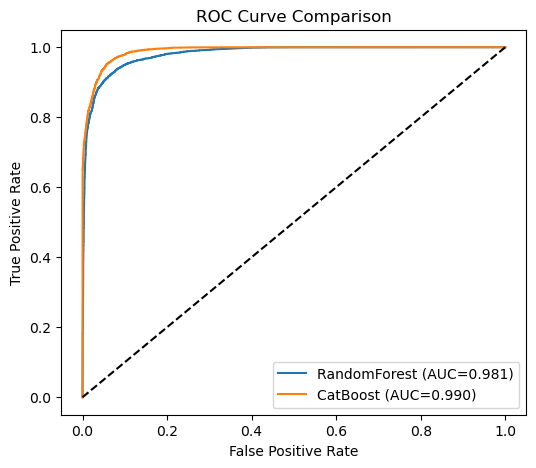

In [16]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)

plt.figure(figsize=(6,5))
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={auc_rf:.3f})")
plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC={auc_cat:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [17]:
results = pd.DataFrame({
    "Model": ["RandomForest", "CatBoost"],
    "Accuracy":  [acc_rf, acc_cat],
    "Precision": [prec_rf, prec_cat],
    "Recall":    [rec_rf, rec_cat],
    "F1-score":  [f1_rf, f1_cat],
    "AUC":       [auc_rf, auc_cat]
})

print(results)


          Model  Accuracy  Precision    Recall  F1-score       AUC
0  RandomForest  0.927742   0.928517  0.918248  0.923354  0.981000
1      CatBoost  0.946373   0.934662  0.953520  0.943996  0.989798


# Part 2: Unsuppervised Learning 

C:\Users\aesha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\aesha\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


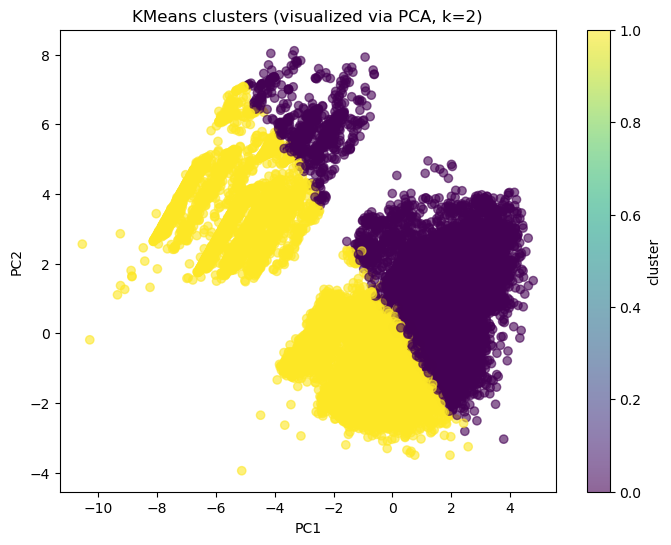

In [18]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Suppose X is your DataFrame of numeric features
# (e.g. result of previous preprocessing / engineering)

# 2. scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. cluster
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# 4. reduce dimension for plotting
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 5. plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.title("KMeans clusters (visualized via PCA, k=2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='cluster')
plt.show()


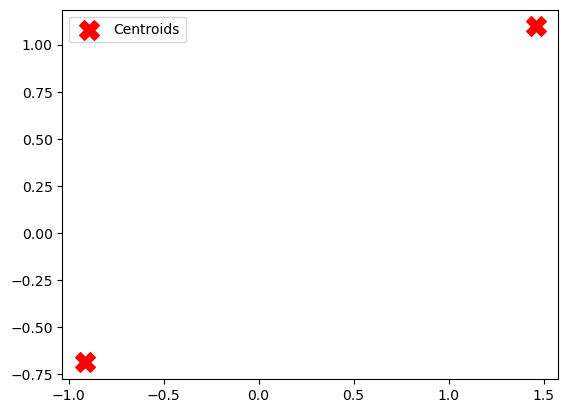

In [19]:
# assuming kmeans is your fitted model
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=200, label='Centroids')
plt.legend()
plt.show()
